In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [22]:
df=pd.read_csv('final_resume_dataset.csv')
df

,category,resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
4806,Java Developer,Over 8+ years of extensive IT experience in de...
4807,IOS Developer,7+ years of experience in designing & developi...
4808,Web Application Developer,Skilled IT Professional with proven success in...
4809,IOS Developer,"Over seven (7+) years of total IT experience, ..."


In [23]:
def clean_data(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # remove symbols
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_category'] = df['category'].apply(clean_data)

In [24]:
df

,category,resume,clean_category
0,Data Science,Skills * Programming Languages: Python (pandas...,data science
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,data science
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",data science
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,data science
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",data science
...,...,...,...
4806,Java Developer,Over 8+ years of extensive IT experience in de...,java developer
4807,IOS Developer,7+ years of experience in designing & developi...,ios developer
4808,Web Application Developer,Skilled IT Professional with proven success in...,web application developer
4809,IOS Developer,"Over seven (7+) years of total IT experience, ...",ios developer


In [25]:
df['clean_resume'] = df['resume'].apply(clean_data)

In [26]:
df

,category,resume,clean_category,clean_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,data science,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,data science,education details may 2013 to may 2017 b e uit...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",data science,areas of interest deep learning control system...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,data science,skills r python sap hana tableau sap hana sql ...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",data science,education details mca ymcaust faridabad haryan...
...,...,...,...,...
4806,Java Developer,Over 8+ years of extensive IT experience in de...,java developer,over 8 years of extensive it experience in des...
4807,IOS Developer,7+ years of experience in designing & developi...,ios developer,7 years of experience in designing developing ...
4808,Web Application Developer,Skilled IT Professional with proven success in...,web application developer,skilled it professional with proven success in...
4809,IOS Developer,"Over seven (7+) years of total IT experience, ...",ios developer,over seven 7 years of total it experience arou...


## Lematization resume text

In [27]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    words = text.split()
    
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return " ".join(words)

df['resume_processed'] = df['clean_resume'].apply(preprocess)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jayso\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jayso\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jayso\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [28]:
df

,category,resume,clean_category,clean_resume,resume_processed
0,Data Science,Skills * Programming Languages: Python (pandas...,data science,skills programming languages python pandas num...,skill programming language python panda numpy ...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,data science,education details may 2013 to may 2017 b e uit...,education detail may 2013 may 2017 b e uit rgp...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",data science,areas of interest deep learning control system...,area interest deep learning control system des...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,data science,skills r python sap hana tableau sap hana sql ...,skill r python sap hana tableau sap hana sql s...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",data science,education details mca ymcaust faridabad haryan...,education detail mca ymcaust faridabad haryana...
...,...,...,...,...,...
4806,Java Developer,Over 8+ years of extensive IT experience in de...,java developer,over 8 years of extensive it experience in des...,8 year extensive experience design development...
4807,IOS Developer,7+ years of experience in designing & developi...,ios developer,7 years of experience in designing developing ...,7 year experience designing developing user in...
4808,Web Application Developer,Skilled IT Professional with proven success in...,web application developer,skilled it professional with proven success in...,skilled professional proven success manning mu...
4809,IOS Developer,"Over seven (7+) years of total IT experience, ...",ios developer,over seven 7 years of total it experience arou...,seven 7 year total experience around 6 year de...


## EDA

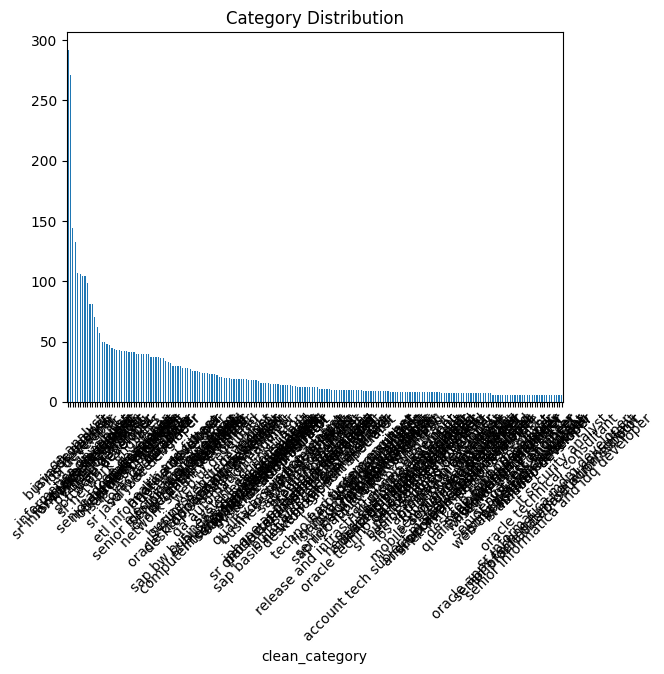

In [29]:

df['clean_category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.xticks(rotation=45)
plt.show()

In [16]:
df['clean_category'].value_counts().sum()

4811

### Here category are more so we take only top 20 categories

In [32]:
top_n = 50

top_categories = df['clean_category'].value_counts().nlargest(top_n).index

df['category_reduced'] = df['clean_category'].apply(
    lambda x: x if x in top_categories else 'Other'
)

In [33]:
top_categories

Index(['business analyst', 'java developer', 'informatica developer',
       'sr informatica developer', 'qa analyst', 'ios developer',
       'java j2ee developer', 'ui developer', 'sr business analyst',
       'sr java developer', 'devops engineer', 'testing', 'sr qa analyst',
       'python developer', 'web developer', 'software developer',
       'quality analyst', 'sr network engineer', 'web designing', 'hr',
       'senior business analyst', 'etl developer', 'hadoop',
       'mechanical engineer', 'hadoop developer', 'operations manager',
       'j2ee developer', 'network engineer', 'sap fico consultant',
       'project manager', 'data science', 'sr java j2ee developer', 'sales',
       'blockchain', 'oracle developer', 'software engineer', 'oracle dba',
       'etl informatica developer', 'qa engineer', 'arts',
       'senior informatica developer', 'database', 'qa tester',
       'health and fitness', 'android developer', 'pmo',
       'electrical engineering', 'dotnet develop

In [34]:
df

,category,resume,clean_category,clean_resume,resume_processed,category_reduced
0,Data Science,Skills * Programming Languages: Python (pandas...,data science,skills programming languages python pandas num...,skill programming language python panda numpy ...,data science
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,data science,education details may 2013 to may 2017 b e uit...,education detail may 2013 may 2017 b e uit rgp...,data science
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",data science,areas of interest deep learning control system...,area interest deep learning control system des...,data science
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,data science,skills r python sap hana tableau sap hana sql ...,skill r python sap hana tableau sap hana sql s...,data science
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",data science,education details mca ymcaust faridabad haryan...,education detail mca ymcaust faridabad haryana...,data science
...,...,...,...,...,...,...
4806,Java Developer,Over 8+ years of extensive IT experience in de...,java developer,over 8 years of extensive it experience in des...,8 year extensive experience design development...,java developer
4807,IOS Developer,7+ years of experience in designing & developi...,ios developer,7 years of experience in designing developing ...,7 year experience designing developing user in...,ios developer
4808,Web Application Developer,Skilled IT Professional with proven success in...,web application developer,skilled it professional with proven success in...,skilled professional proven success manning mu...,Other
4809,IOS Developer,"Over seven (7+) years of total IT experience, ...",ios developer,over seven 7 years of total it experience arou...,seven 7 year total experience around 6 year de...,ios developer


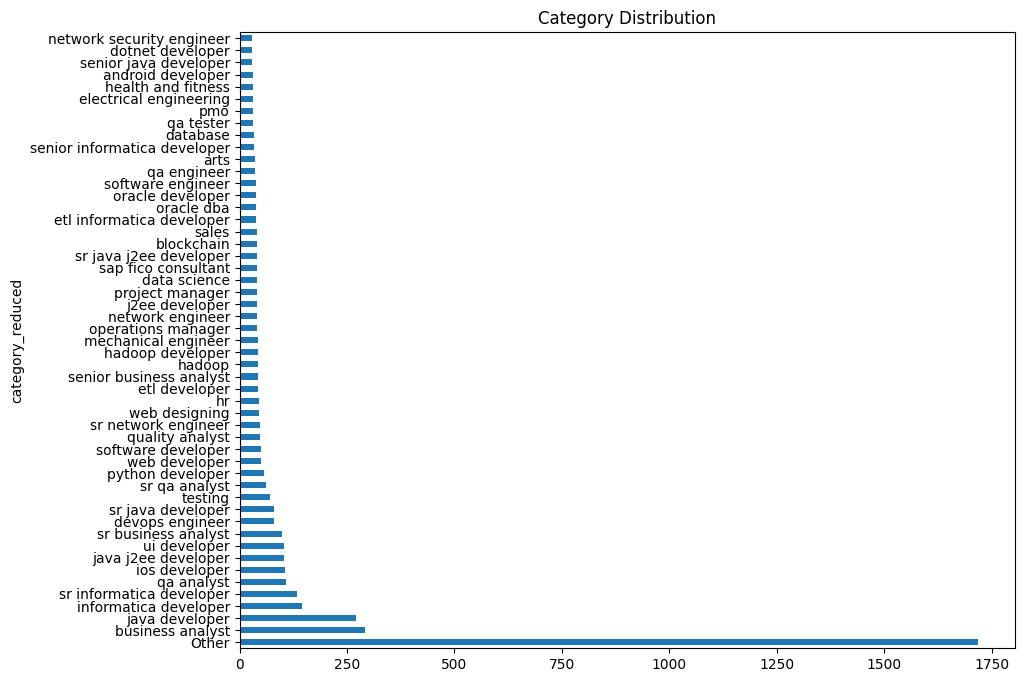

In [35]:
df['category_reduced'].value_counts().plot(kind='barh',figsize=(10, 8))
plt.title("Category Distribution")
plt.show()

In [36]:
new_df = df[df['category_reduced'] != 'Other']

In [41]:
new_df

,category,resume,clean_category,clean_resume,resume_processed,category_reduced
0,Data Science,Skills * Programming Languages: Python (pandas...,data science,skills programming languages python pandas num...,skill programming language python panda numpy ...,data science
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,data science,education details may 2013 to may 2017 b e uit...,education detail may 2013 may 2017 b e uit rgp...,data science
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",data science,areas of interest deep learning control system...,area interest deep learning control system des...,data science
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,data science,skills r python sap hana tableau sap hana sql ...,skill r python sap hana tableau sap hana sql s...,data science
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",data science,education details mca ymcaust faridabad haryan...,education detail mca ymcaust faridabad haryana...,data science
...,...,...,...,...,...,...
4805,UI Developer,Over 7 years of development experience with HT...,ui developer,over 7 years of development experience with ht...,7 year development experience html html5 xhtml...,ui developer
4806,Java Developer,Over 8+ years of extensive IT experience in de...,java developer,over 8 years of extensive it experience in des...,8 year extensive experience design development...,java developer
4807,IOS Developer,7+ years of experience in designing & developi...,ios developer,7 years of experience in designing developing ...,7 year experience designing developing user in...,ios developer
4809,IOS Developer,"Over seven (7+) years of total IT experience, ...",ios developer,over seven 7 years of total it experience arou...,seven 7 year total experience around 6 year de...,ios developer


C:\Users\jayso\AppData\Local\Temp\ipykernel_3724\1820391075.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['resume_length'] = new_df['resume_processed'].apply(len)


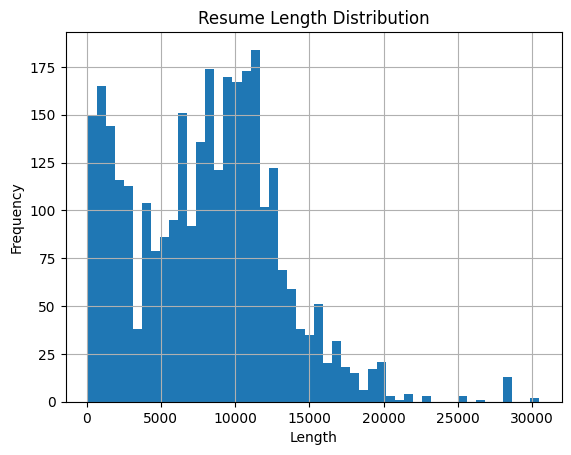

In [42]:
## Text Length Analysis
new_df['resume_length'] = new_df['resume_processed'].apply(len)

new_df['resume_length'].hist(bins=50)
plt.title("Resume Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

C:\Users\jayso\AppData\Local\Temp\ipykernel_3724\1584960593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['word_count'] = new_df['resume_processed'].apply(lambda x: len(x.split()))


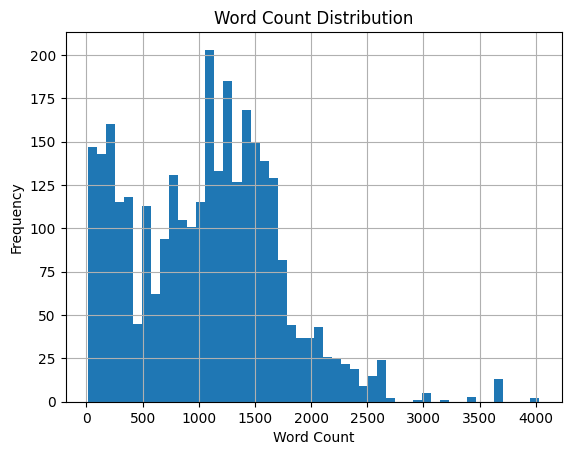

In [43]:
# Words per Resume
new_df['word_count'] = new_df['resume_processed'].apply(lambda x: len(x.split()))

new_df['word_count'].hist(bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [44]:
new_df

,category,resume,clean_category,clean_resume,resume_processed,category_reduced,resume_length,word_count
0,Data Science,Skills * Programming Languages: Python (pandas...,data science,skills programming languages python pandas num...,skill programming language python panda numpy ...,data science,3875,507
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,data science,education details may 2013 to may 2017 b e uit...,education detail may 2013 may 2017 b e uit rgp...,data science,1019,139
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",data science,areas of interest deep learning control system...,area interest deep learning control system des...,data science,1504,204
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,data science,skills r python sap hana tableau sap hana sql ...,skill r python sap hana tableau sap hana sql s...,data science,5662,747
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",data science,education details mca ymcaust faridabad haryan...,education detail mca ymcaust faridabad haryana...,data science,365,55
...,...,...,...,...,...,...,...,...
4805,UI Developer,Over 7 years of development experience with HT...,ui developer,over 7 years of development experience with ht...,7 year development experience html html5 xhtml...,ui developer,14277,1951
4806,Java Developer,Over 8+ years of extensive IT experience in de...,java developer,over 8 years of extensive it experience in des...,8 year extensive experience design development...,java developer,14105,1971
4807,IOS Developer,7+ years of experience in designing & developi...,ios developer,7 years of experience in designing developing ...,7 year experience designing developing user in...,ios developer,10440,1420
4809,IOS Developer,"Over seven (7+) years of total IT experience, ...",ios developer,over seven 7 years of total it experience arou...,seven 7 year total experience around 6 year de...,ios developer,8366,1161


## Most common words in resume

In [45]:

from collections import Counter

all_words = " ".join(new_df['resume_processed']).split()
common_words = Counter(all_words).most_common(20)

print(common_words)

[('using', 45582), ('data', 43561), ('application', 32222), ('business', 30838), ('test', 30166), ('testing', 29751), ('sql', 28205), ('requirement', 27330), ('used', 23046), ('experience', 22748), ('system', 21910), ('web', 21308), ('developed', 21084), ('project', 20508), ('development', 20103), ('server', 18858), ('design', 18411), ('database', 17864), ('involved', 17806), ('user', 17721)]


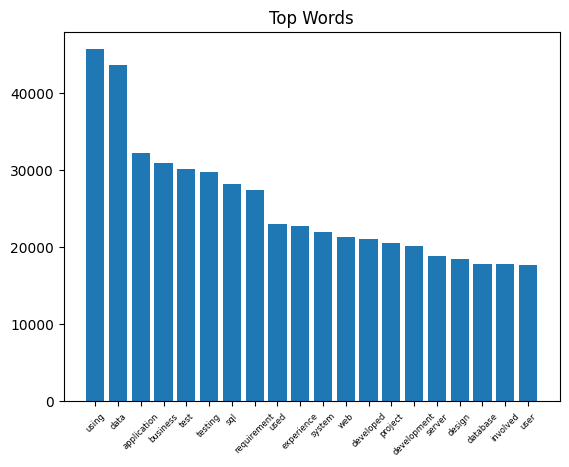

In [50]:
words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=45,fontsize=6)
plt.title("Top Words")
plt.show()

In [51]:
new_df.to_csv('processed_resume_dataset.csv', index=False)

In [52]:
data=pd.read_csv('processed_resume_dataset.csv')
data

,category,resume,clean_category,clean_resume,resume_processed,category_reduced,resume_length,word_count
0,Data Science,Skills * Programming Languages: Python (pandas...,data science,skills programming languages python pandas num...,skill programming language python panda numpy ...,data science,3875,507
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,data science,education details may 2013 to may 2017 b e uit...,education detail may 2013 may 2017 b e uit rgp...,data science,1019,139
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",data science,areas of interest deep learning control system...,area interest deep learning control system des...,data science,1504,204
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,data science,skills r python sap hana tableau sap hana sql ...,skill r python sap hana tableau sap hana sql s...,data science,5662,747
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",data science,education details mca ymcaust faridabad haryan...,education detail mca ymcaust faridabad haryana...,data science,365,55
...,...,...,...,...,...,...,...,...
3088,UI Developer,Over 7 years of development experience with HT...,ui developer,over 7 years of development experience with ht...,7 year development experience html html5 xhtml...,ui developer,14277,1951
3089,Java Developer,Over 8+ years of extensive IT experience in de...,java developer,over 8 years of extensive it experience in des...,8 year extensive experience design development...,java developer,14105,1971
3090,IOS Developer,7+ years of experience in designing & developi...,ios developer,7 years of experience in designing developing ...,7 year experience designing developing user in...,ios developer,10440,1420
3091,IOS Developer,"Over seven (7+) years of total IT experience, ...",ios developer,over seven 7 years of total it experience arou...,seven 7 year total experience around 6 year de...,ios developer,8366,1161


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3093 entries, 0 to 3092
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   category          3093 non-null   object
 1   resume            3093 non-null   object
 2   clean_category    3093 non-null   object
 3   clean_resume      3093 non-null   object
 4   resume_processed  3093 non-null   object
 5   category_reduced  3093 non-null   object
 6   resume_length     3093 non-null   int64 
 7   word_count        3093 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 193.4+ KB
